In [1179]:
import pandas as pd

In [1180]:
df1 = pd.read_csv('Titanic-Dataset.csv')
df2 = pd.read_csv('tested.csv')

df = pd.concat([df1, df2], axis = 0, ignore_index=True)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [1181]:
df.shape

(1309, 12)

In [1182]:
df.isnull().mean() * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            20.091673
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.076394
Cabin          77.463713
Embarked        0.152788
dtype: float64

In [1183]:
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
df['Age'].isna().sum()

np.int64(0)

In [1184]:
df = df.drop('Cabin', axis = 1)

In [1185]:
mode_Embarked = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(mode_Embarked)
df['Embarked'].isna().sum()

np.int64(0)

In [1186]:
median_fare = df['Fare'].median()
df['Fare'] = df['Fare'].fillna(median_fare)
df['Fare'].isna().sum()

np.int64(0)

In [1187]:
df.isnull().mean() * 100

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Embarked       0.0
dtype: float64

In [1188]:
df.duplicated().sum()

np.int64(0)

In [1189]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
dtype: object

In [1190]:
df['Age'] = df['Age'].astype(int)

In [1191]:
for col in ['Sex', 'Embarked']:
    df[col] = df[col].astype('category')  

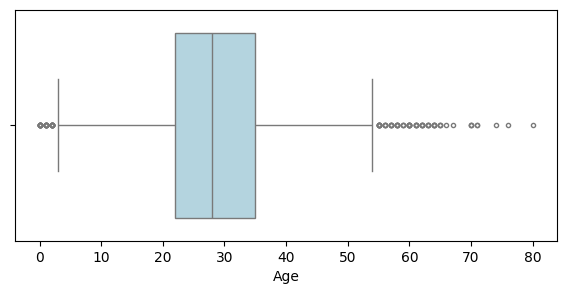

In [1192]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,3))
sns.boxplot(x=df['Age'], fliersize=3, color = 'lightblue')
plt.show()

In [1193]:
sorted(df['Age'].unique().tolist())[:10]

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [1194]:
sorted(df['Age'].unique().tolist())[::-1][:10]

[80, 76, 74, 71, 70, 67, 66, 65, 64, 63]

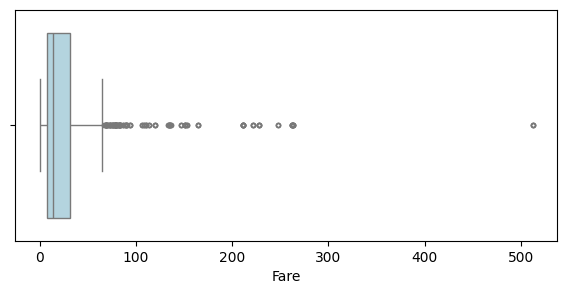

13.06340718105424

In [1195]:
plt.figure(figsize=(7,3))
sns.boxplot(x=df['Fare'], fliersize=3, color = 'lightblue')
plt.show()

Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_b = Q1 - 1.5 * IQR
upper_b = Q3 + 1.5 * IQR
outliers = df[(df['Fare'] < lower_b) | (df['Fare'] > upper_b)]
outliers.shape[0]/df.shape[0]*100 #процент выбросов в цене билета

In [1196]:
df['FamSize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamSize'] == 1).astype(int)

In [1197]:
age_bins = [0, 12, 19, 39, 59, 100]
age_labels = ['Child', 'Teen', 'Adult', 'Middle', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

In [1198]:
fare_bins_manual = [0, 20, 50, 100, 550]
fare_labels_manual = ['Low', 'Medium', 'High', 'Very High']
df['FareBand'] = pd.cut(df['Fare'], bins=fare_bins_manual, labels=fare_labels_manual, right=False)

In [1199]:
print(df['FareBand'].value_counts())

FareBand
Low          753
Medium       314
High         158
Very High     84
Name: count, dtype: int64


In [1200]:
print(df.groupby('FareBand')['Fare'].agg(['min', 'max']))

                min       max
FareBand                     
Low          0.0000   19.9667
Medium      20.2125   49.5042
High        50.0000   93.5000
Very High  106.4250  512.3292


/var/folders/lt/djbn4brj4ks00s3w1dv4tmw40000gn/T/ipykernel_43846/2548828735.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('FareBand')['Fare'].agg(['min', 'max']))


In [1201]:
import numpy as np

conditions = [
    df['FamSize'] == 1,
    df['FamSize'].between(2, 3),
    df['FamSize'] >= 4
]
choices = ['Alone', 'Small Family', 'Large Family']
df['FamType'] = np.select(conditions, choices, default='Unknown')

In [1202]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamSize,IsAlone,AgeGroup,FareBand,FamType
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S,2,0,Adult,Low,Small Family
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C,2,0,Adult,High,Small Family
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S,1,1,Adult,Low,Alone
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S,2,0,Adult,High,Small Family
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S,1,1,Adult,Low,Alone


In [1203]:
df.to_csv('titanic_for_dashboard.csv', index=False)